<a href="https://colab.research.google.com/github/rajattiwari010/01_neural_network_regression_in_tensorflow_tutorial_1/blob/MY-REPO's/Oorja_Nest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# prompt: code to use gpu

import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print("Please install GPU version of TF")


Num GPUs Available:  1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Default GPU Device: /device:GPU:0


In [ ]:
import zipfile
import os
from google.colab import drive
drive.mount('/content/drive')
# Path to the folder where the ZIP files are uploaded
zip_folder = "/content/drive/MyDrive/Annotate/"

Extract all ZIP files in the folder
for filename in os.listdir(zip_folder):
    if filename.endswith(".zip"):
        with zipfile.ZipFile(os.path.join(zip_folder, filename), 'r') as zip_ref:
            extract_path = os.path.join(zip_folder, filename.replace('.zip', ''))
            zip_ref.extractall(extract_path)
            print(f"Extracted: {filename} to {extract_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil

# Paths to the three datasets
dataset1 = "/content/drive/MyDrive/Annotate/1"
dataset2 = "/content/drive/MyDrive/Annotate/2"
dataset3 = "/content/drive/MyDrive/Annotate/3"

# Combined dataset paths
combined_train_images = "/content/drive/MyDrive/Annotate1/Combined_Dataset/train"
combined_test_images = "/content/drive/MyDrive/Annotate1/Combined_Dataset/test"
combined_val_images = "/content/drive/MyDrive/Annotate1/Combined_Dataset/valid"

# Create combined folder structure if it doesn't exist
os.makedirs(combined_train_images, exist_ok=True)
os.makedirs(combined_test_images, exist_ok=True)
os.makedirs(combined_val_images, exist_ok=True)

# Function to copy images from one dataset to the combined dataset
def copy_images(src_dir, dest_dir):
    # Check if the source directory exists before listing its contents
    if os.path.exists(src_dir):
        for file in os.listdir(src_dir):
            if file.endswith((".jpg", ".png")):
                shutil.copy(os.path.join(src_dir, file), os.path.join(dest_dir, file))
    else:
        print(f"Warning: Source directory not found: {src_dir}")

# Copy images for train, test, and validation from all datasets
datasets = [dataset1, dataset2, dataset3]
for dataset in datasets:
    copy_images(os.path.join(dataset, "train"), combined_train_images)
    copy_images(os.path.join(dataset, "test"), combined_test_images)
    copy_images(os.path.join(dataset, "valid"), combined_val_images)

print("All datasets merged successfully!")


All datasets merged successfully!


In [ ]:
import json
import os
dataset1 = "/content/drive/MyDrive/Annotate/1"
dataset2 = "/content/drive/MyDrive/Annotate/2"

# Combined dataset paths
combined_train_annotations = "/content/drive/MyDrive/Annotate1/Combined_Dataset/train/_annotations.coco.json"
combined_test_annotations = "/content/drive/MyDrive/Annotate1/Combined_Dataset/test/_annotations.coco.json"
combined_val_annotations = "/content/drive/MyDrive/Annotate1/Combined_Dataset/valid/_annotations.coco.json"

# Function to merge COCO annotations
def merge_coco_annotations(datasets, combined_annotation_path):
    merged_annotations = {
        "images": [],
        "annotations": [],
        "categories": []
    }

    # Track IDs to avoid duplicates
    image_id_offset = 0
    annotation_id_offset = 0

    for dataset in datasets:
        # Load annotations
        annotation_path = os.path.join(dataset, "_annotations.coco.json")
        with open(annotation_path, "r") as file:
            annotations = json.load(file)

        # Adjust image and annotation IDs
        for image in annotations["images"]:
            image["id"] += image_id_offset

        for annotation in annotations["annotations"]:
            annotation["image_id"] += image_id_offset
            annotation["id"] += annotation_id_offset

        # Add to merged annotations
        merged_annotations["images"].extend(annotations["images"])
        merged_annotations["annotations"].extend(annotations["annotations"])

        # Ensure categories are consistent (add only once)
        if not merged_annotations["categories"]:
            merged_annotations["categories"] = annotations["categories"]

        # Update offsets
        image_id_offset = max(image["id"] for image in merged_annotations["images"]) + 1
        annotation_id_offset = max(annotation["id"] for annotation in merged_annotations["annotations"]) + 1

    # Save merged annotations
    with open(combined_annotation_path, "w") as file:
        json.dump(merged_annotations, file)

    print(f"Annotations merged and saved to {combined_annotation_path}!")

# Merge train, test, and val annotations
datasets = [dataset1, dataset2]

merge_coco_annotations([os.path.join(dataset, "train") for dataset in datasets], combined_train_annotations)
merge_coco_annotations([os.path.join(dataset, "test") for dataset in datasets], combined_test_annotations)
merge_coco_annotations([os.path.join(dataset, "valid") for dataset in datasets], combined_val_annotations)


Annotations merged and saved to /content/drive/MyDrive/Annotate1/Combined_Dataset/train/_annotations.coco.json!
Annotations merged and saved to /content/drive/MyDrive/Annotate1/Combined_Dataset/test/_annotations.coco.json!
Annotations merged and saved to /content/drive/MyDrive/Annotate1/Combined_Dataset/valid/_annotations.coco.json!


In [ ]:
!pip install pycocotools

In [ ]:
from pycocotools.coco import COCO
import numpy as np
import cv2
import os
from tqdm import tqdm

def generate_masks(coco_annotation_path, image_folder, output_mask_folder):
    # Create output folder if it doesn't exist
    os.makedirs(output_mask_folder, exist_ok=True)

    # Load COCO annotations
    coco = COCO(coco_annotation_path)
    image_ids = coco.getImgIds()

    for image_id in tqdm(image_ids, desc="Generating masks"):
        # Load the image info
        image_info = coco.loadImgs(image_id)[0]
        image_filename = image_info["file_name"]

        # Create a blank mask
        width, height = image_info["width"], image_info["height"]
        mask = np.zeros((height, width), dtype=np.uint8)

        # Get all annotations for the image
        annotation_ids = coco.getAnnIds(imgIds=image_id)
        annotations = coco.loadAnns(annotation_ids)

        # Draw each annotation onto the mask
        for annotation in annotations:
            segmentation = annotation["segmentation"]
            # Convert segmentation to polygons and draw it
            for seg in segmentation:
                polygon = np.array(seg).reshape(-1, 2).astype(np.int32)
                cv2.fillPoly(mask, [polygon], color=1)

        # Save the mask as a PNG file
        mask_filename = os.path.splitext(image_filename)[0] + "_mask.png"
        mask_path = os.path.join(output_mask_folder, mask_filename)
        cv2.imwrite(mask_path, mask * 255)  # Scale mask to 0-255 for saving

    print(f"Masks saved to {output_mask_folder}!")

# Paths to combined dataset
train_annotations = "/content/drive/MyDrive/Annotate1/Combined_Dataset/train/_annotations.coco.json"
train_images = "/content/drive/MyDrive/Annotate1/Combined_Dataset/train"
train_masks_output = "/content/drive/MyDrive/Annotate1/Combined_Dataset/train/masks"

# Generate masks for train, test, and val
generate_masks(train_annotations, train_images, train_masks_output)

# Repeat for test and val
generate_masks("/content/drive/MyDrive/Annotate1/Combined_Dataset/test/_annotations.coco.json",
               "/content/drive/MyDrive/Annotate1/Combined_Dataset/test",
               "/content/drive/MyDrive/Annotate1/Combined_Dataset/test/masks")

generate_masks("/content/drive/MyDrive/Annotate1/Combined_Dataset/valid/_annotations.coco.json",
               "/content/drive/MyDrive/Annotate1/Combined_Dataset/valid",
               "/content/drive/MyDrive/Annotate1/Combined_Dataset/valid/masks")


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


Generating masks: 100%|██████████| 613/613 [00:04<00:00, 128.58it/s]


Masks saved to /content/drive/MyDrive/Annotate1/Combined_Dataset/train/masks!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Generating masks: 100%|██████████| 91/91 [00:00<00:00, 159.04it/s]


Masks saved to /content/drive/MyDrive/Annotate1/Combined_Dataset/test/masks!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Generating masks: 100%|██████████| 175/175 [00:01<00:00, 141.03it/s]

Masks saved to /content/drive/MyDrive/Annotate1/Combined_Dataset/valid/masks!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import cv2
import os
import numpy as np

# Paths to images and masks
train_image_dir = "/content/drive/MyDrive/Annotate1/Combined_Dataset/train"
train_mask_dir = "/content/drive/MyDrive/Annotate1/Combined_Dataset/train/masks"

val_image_dir = "/content/drive/MyDrive/Annotate1/Combined_Dataset/valid"
val_mask_dir = "/content/drive/MyDrive/Annotate1/Combined_Dataset/valid/masks"

test_image_dir = "/content/drive/MyDrive/Annotate1/Combined_Dataset/test"
test_mask_dir = "/content/drive/MyDrive/Annotate1/Combined_Dataset/test/masks"

def load_data(image_dir, mask_dir):
    image_files = [f for f in os.listdir(image_dir) if f.endswith((".jpg", ".png")) and not f.endswith("_mask.png")]
    mask_files = [f for f in os.listdir(mask_dir) if f.endswith(("_mask.png"))]

    image_files.sort()
    mask_files.sort()

    images, masks = [], []

    for img_file in image_files:
        base_name = os.path.splitext(img_file)[0]
        mask_file = base_name + "_mask.png"

        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)

        if os.path.exists(mask_path):
            img = cv2.imread(img_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if img is not None and mask is not None:
                img = cv2.resize(img, (128, 128))
                mask = cv2.resize(mask, (128, 128))

                images.append(img)
                masks.append(mask)
            else:
                print(f"Warning: Couldn't load {img_path} or {mask_path}")
        else:
            print(f"Warning: No mask found for image {img_file}")

    images = np.array(images).astype('float32') / 255.0
    masks = (np.expand_dims(np.array(masks), axis=-1) > 0).astype('float32')

    return images, masks

# Load datasets
X_train, y_train = load_data(train_image_dir, train_mask_dir)
X_val, y_val = load_data(val_image_dir, val_mask_dir)
X_test, y_test = load_data(test_image_dir, test_mask_dir)

# Define U-Net model
def unet_model(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = models.Model(inputs=[inputs], outputs=[outputs])

    return model

# Create the U-Net model
unet = unet_model()

# Compile the model
unet.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
             loss='binary_crossentropy',
             metrics=['accuracy'])

# Summary of the model
unet.summary()

# Training and validation
history = unet.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_val, y_val)
)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_76 (Conv2D)  │ (None, 128, 128,  │      1,792 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_77 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_76[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 64, 64,    │          0 │ conv2d_77[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_78 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_16… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_79 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_78[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 32, 32,    │          0 │ conv2d_79[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_80 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_17… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_81 (Conv2D)  │ (None, 32, 32,    │    590,080 │ conv2d_80[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 16, 16,    │          0 │ conv2d_81[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_82 (Conv2D)  │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_18… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_83 (Conv2D)  │ (None, 16, 16,    │  2,359,808 │ conv2d_82[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_19    │ (None, 8, 8, 512) │          0 │ conv2d_83[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_84 (Conv2D)  │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_19… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_85 (Conv2D)  │ (None, 8, 8,      │  9,438,208 │ conv2d_84[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_16 │ (None, 16, 16,    │  2,097,664 │ conv2d_85[0][0]   │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_16      │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_128']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


39/39 ━━━━━━━━━━━━━━━━━━━━ 26s 401ms/step - accuracy: 0.9449 - loss: 0.5479 - val_accuracy: 0.9356 - val_loss: 0.3522
Epoch 2/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 252ms/step - accuracy: 0.9452 - loss: 0.2938 - val_accuracy: 0.9356 - val_loss: 0.2215
Epoch 3/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 250ms/step - accuracy: 0.9498 - loss: 0.1820 - val_accuracy: 0.9356 - val_loss: 0.2110
Epoch 4/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 258ms/step - accuracy: 0.9497 - loss: 0.1783 - val_accuracy: 0.9356 - val_loss: 0.2071
Epoch 5/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 256ms/step - accuracy: 0.9435 - loss: 0.1570 - val_accuracy: 0.9356 - val_loss: 0.1555
Epoch 6/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 245ms/step - accuracy: 0.9513 - loss: 0.1279 - val_accuracy: 0.9356 - val_loss: 0.1552
Epoch 7/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 256ms/step - accuracy: 0.9478 - loss: 0.1510 - val_accuracy: 0.9356 - val_loss: 0.1382
Epoch 8/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 247ms/step - accuracy: 0.9416 - loss: 0.1281 - val_accuracy: 0.935

In [ ]:
train_loss, train_accuracy = unet.evaluate(X_train, y_train)
print(f"Training Loss: {train_loss:.4f}")
print(f"Training Accuracy: {train_accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 426ms/step - accuracy: 0.9961 - loss: 0.0092
Training Loss: 0.0053
Training Accuracy: 0.9977


In [ ]:
# Testing
test_loss, test_accuracy = unet.evaluate(X_test, y_test, batch_size=16)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.9264 - loss: 0.5696
Test Loss: 0.3279
Test Accuracy: 0.9575


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_96']
Received: inputs=Tensor(shape=(32, 128, 128, 3))
  warnings.warn(msg)


3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 7s/step


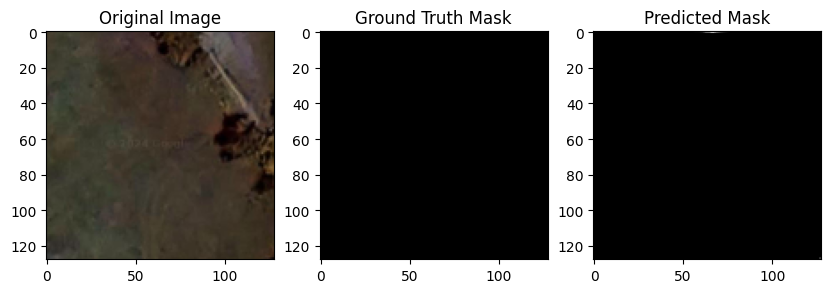

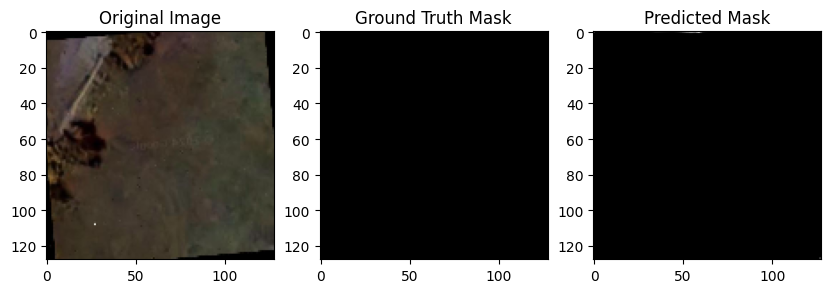

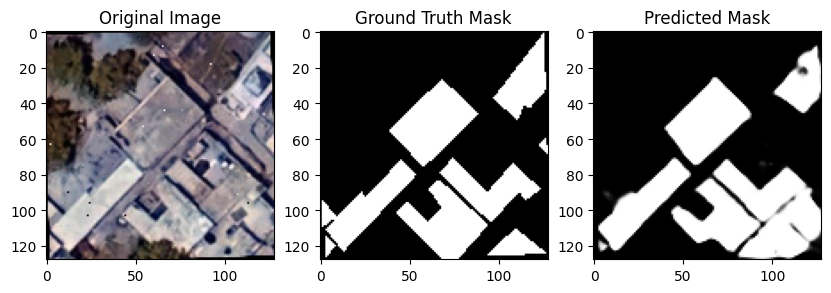

In [ ]:
import matplotlib.pyplot as plt

# Predict on the test set
predictions = unet.predict(X_test)

# Visualize a few samples
for i in range(3):  # Show 3 samples
    plt.figure(figsize=(10, 5))

    # Original Image
    plt.subplot(1, 3, 1)
    plt.imshow(X_test[i])
    plt.title("Original Image")

    # Ground Truth Mask
    plt.subplot(1, 3, 2)
    plt.imshow(y_test[i].squeeze(), cmap='gray')
    plt.title("Ground Truth Mask")

    # Predicted Mask
    plt.subplot(1, 3, 3)
    plt.imshow(predictions[i].squeeze(), cmap='gray')
    plt.title("Predicted Mask")

    plt.show()


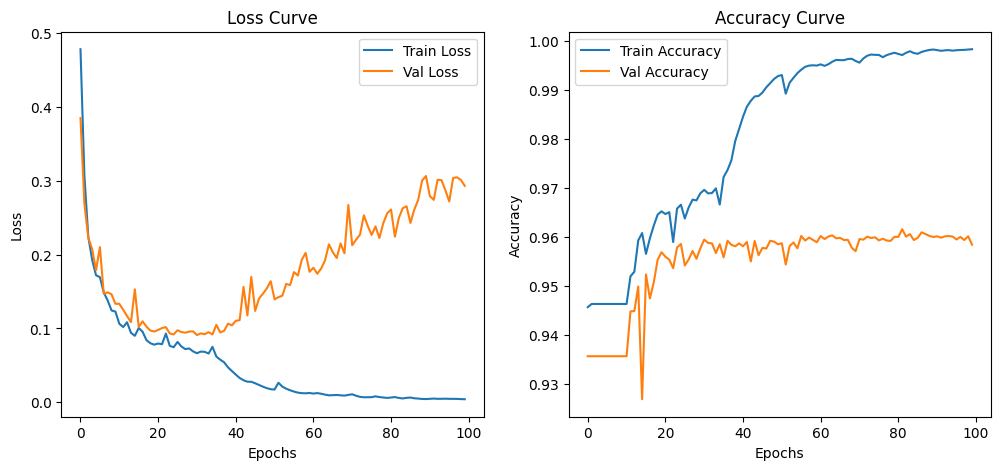

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss
def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Loss Curve
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()

    # Accuracy Curve
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curve')
    plt.legend()

    plt.show()

# Call the function
plot_training_history(history)


In [ ]:
import tensorflow.keras.backend as K

def iou_metric(y_true, y_pred):
    y_pred = K.cast(y_pred > 0.5, dtype='float32')  # Convert to binary mask
    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection
    return (intersection + K.epsilon()) / (union + K.epsilon())

# Evaluate IoU on test set
y_pred_test = unet.predict(X_test)
iou_score = iou_metric(y_test, y_pred_test).numpy()

print(f"IoU Score on Test Set: {iou_score:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step
IoU Score on Test Set: 0.4968


In [ ]:
import tensorflow.keras.backend as K

# Dice coefficient metric
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# IoU metric
def iou_metric(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Compile the model with new metrics
unet.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
             loss='binary_crossentropy',
             metrics=['accuracy', dice_coefficient, iou_metric])


In [ ]:
test_loss, test_acc, test_dice, test_iou = unet.evaluate(X_test, y_test, batch_size=16)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Dice Coefficient: {test_dice:.4f}")
print(f"Test IoU: {test_iou:.4f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step - accuracy: 0.9264 - dice_coefficient: 0.6390 - iou_metric: 0.5145 - loss: 0.5696
Test Loss: 0.3279
Test Accuracy: 0.9575
Test Dice Coefficient: 0.5374
Test IoU: 0.4560


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_96']
Received: inputs=Tensor(shape=(32, 128, 128, 3))
  warnings.warn(msg)


2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_96']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 628ms/step


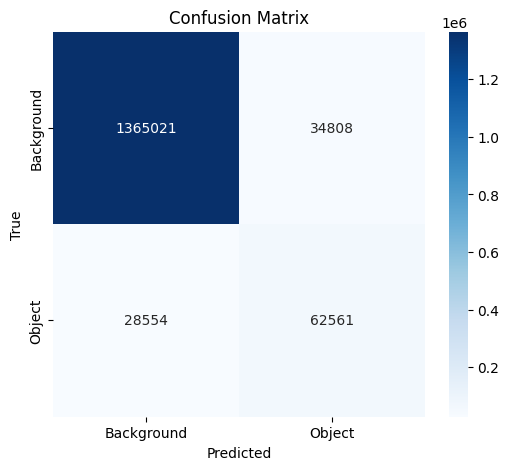

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = (y_pred.flatten() > 0.5).astype(int)  # Convert predictions to binary

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Background", "Object"], yticklabels=["Background", "Object"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

#confusion matrix
y_pred_test = unet.predict(X_test)
plot_confusion_matrix(y_test, y_pred_test)


In [ ]:
from sklearn.metrics import confusion_matrix

# Get predictions and flatten
y_pred = (unet.predict(X_test) > 0.5).astype("int32")
y_pred_flat = y_pred.flatten()
y_true_flat = y_test.flatten()

# Compute confusion matrix
cm = confusion_matrix(y_true_flat, y_pred_flat)
print("Confusion Matrix:")
print(cm)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step
Confusion Matrix:
[[1365021   34808]
 [  28554   62561]]


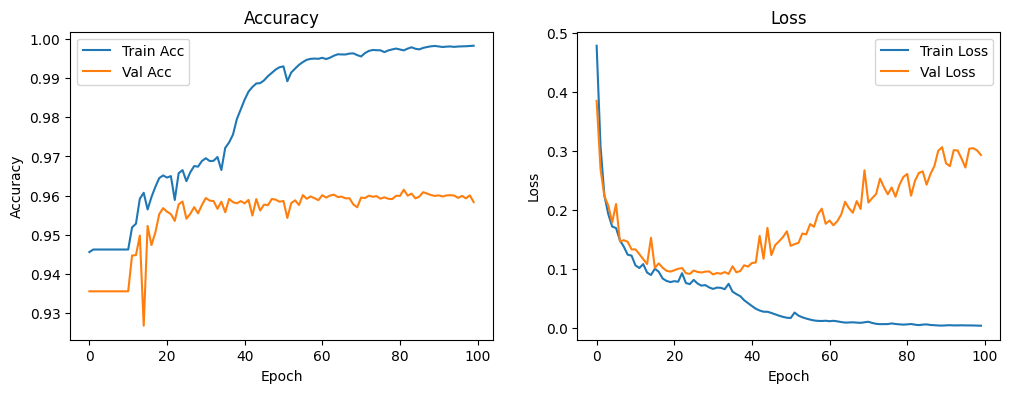

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# EarlyStopping: Stop training when val_loss doesn't improve for 10 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

# Optional: Save the best model (useful when val_loss improves earlier)
checkpoint = ModelCheckpoint("best_unet_model.h5", monitor='val_loss', save_best_only=True, verbose=1)

# Fit the model
history = unet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9833 - dice_coefficient: 0.7218 - iou_metric: 0.5674 - loss: 0.0427
Epoch 1: val_loss improved from inf to 0.18530, saving model to best_unet_model.h5


39/39 ━━━━━━━━━━━━━━━━━━━━ 17s 448ms/step - accuracy: 0.9833 - dice_coefficient: 0.7225 - iou_metric: 0.5685 - loss: 0.0426 - val_accuracy: 0.9493 - val_dice_coefficient: 0.3239 - val_iou_metric: 0.2331 - val_loss: 0.1853
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9897 - dice_coefficient: 0.8458 - iou_metric: 0.7357 - loss: 0.0270
Epoch 2: val_loss did not improve from 0.18530
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 261ms/step - accuracy: 0.9897 - dice_coefficient: 0.8466 - iou_metric: 0.7369 - loss: 0.0268 - val_accuracy: 0.9530 - val_dice_coefficient: 0.3446 - val_iou_metric: 0.2426 - val_loss: 0.1874
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9953 - dice_coefficient: 0.9192 - iou_metric: 0.8574 - loss: 0.0122
Epoch 3: val_loss improved from 0.18530 to 0.16515, saving model to best_unet_model.h5


39/39 ━━━━━━━━━━━━━━━━━━━━ 17s 451ms/step - accuracy: 0.9953 - dice_coefficient: 0.9192 - iou_metric: 0.8576 - loss: 0.0122 - val_accuracy: 0.9568 - val_dice_coefficient: 0.3831 - val_iou_metric: 0.2696 - val_loss: 0.1652
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9969 - dice_coefficient: 0.9141 - iou_metric: 0.8720 - loss: 0.0084
Epoch 4: val_loss did not improve from 0.16515
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 246ms/step - accuracy: 0.9969 - dice_coefficient: 0.9147 - iou_metric: 0.8726 - loss: 0.0084 - val_accuracy: 0.9562 - val_dice_coefficient: 0.3964 - val_iou_metric: 0.2851 - val_loss: 0.2124
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9977 - dice_coefficient: 0.9615 - iou_metric: 0.9261 - loss: 0.0059
Epoch 5: val_loss did not improve from 0.16515
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 249ms/step - accuracy: 0.9977 - dice_coefficient: 0.9616 - iou_metric: 0.9262 - loss: 0.0059 - val_accuracy: 0.9562 - val_dice_coefficient: 0.4190 - val_iou_metr

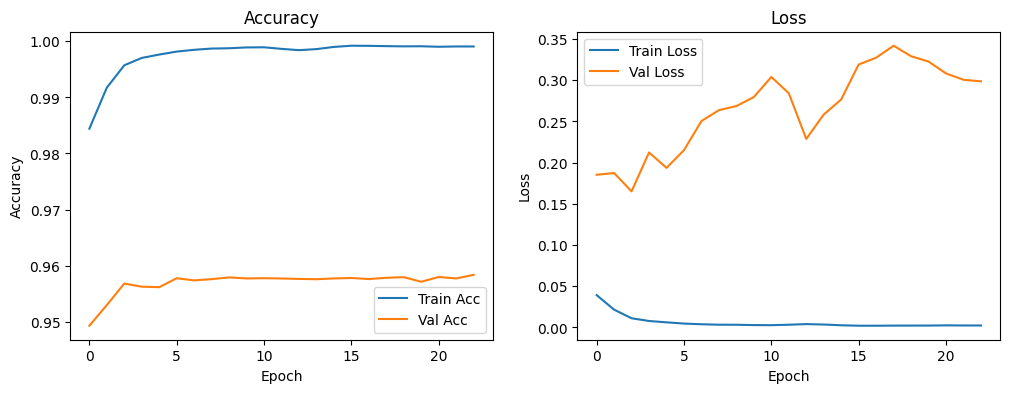

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()
